R Data Cleaning and Visualization - <08/09/2026> - <gerbla7878>

In [1]:
library(readxl)
library(writexl)
library(dplyr)
library(ggplot2)
library(corrplot)
library(IRdisplay)

student_id <- "gerbla7878"
todays_date <- format(Sys.Date(), "%Y-%m-%d")

file_path <- "C:/Files/Excel/DA_PythonR/AirBnBSummary_v2.xlsx"

df <- read_excel(file_path)

df_cleaned <- df

df_cleaned <- distinct(df_cleaned)

df_cleaned[df_cleaned == "Private room"] <- "Private Room"

numeric_columns <- names(df_cleaned)[sapply(df_cleaned, is.numeric)]

for (col in numeric_columns) {
    median_value <- median(df_cleaned[[col]], na.rm = TRUE)
    df_cleaned[[col]][is.na(df_cleaned[[col]])] <- median_value
}

outlier_columns <- c(
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
)

outlier_rows <- rep(FALSE, nrow(df_cleaned))

for (col in outlier_columns) {
    Q1 <- quantile(df_cleaned[[col]], 0.25, na.rm = TRUE)
    Q3 <- quantile(df_cleaned[[col]], 0.75, na.rm = TRUE)
    IQR_value <- Q3 - Q1

    lower_bound <- Q1 - 1.5 * IQR_value
    upper_bound <- Q3 + 1.5 * IQR_value

    outlier_rows <- outlier_rows |
        df_cleaned[[col]] < lower_bound |
        df_cleaned[[col]] > upper_bound
}

df_cleaned <- df_cleaned[!outlier_rows, ]

print(dim(df_cleaned))

cleaned_file_path <- "C:/Files/Excel/DA_PythonR/AirBnBSummary_v2_R_Cleaned.xlsx"

write_xlsx(df_cleaned, cleaned_file_path)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



[1] 1205   10


In [2]:
total_listings <- nrow(df_cleaned)

minimum_price <- min(df_cleaned$price, na.rm = TRUE)

maximum_price <- max(df_cleaned$price, na.rm = TRUE)

mean_price <- mean(df_cleaned$price, na.rm = TRUE)

median_reviews <- median(
    df_cleaned$number_of_reviews,
    na.rm = TRUE
)

mode_minimum_nights <- as.numeric(
    names(
        which.max(
            table(df_cleaned$minimum_nights)
        )
    )
)

std_price <- sd(df_cleaned$price, na.rm = TRUE)

price_availability_corr <- cor(
    df_cleaned$price,
    df_cleaned$availability_365,
    use = "complete.obs"
)

display_markdown(
    paste("###", student_id, "-", todays_date)
)

print(paste(
    "Total Count of Listings:",
    total_listings
))

print(paste(
    "Minimum Price:",
    minimum_price
))

print(paste(
    "Maximum Price:",
    maximum_price
))

print(paste(
    "Mean Price:",
    mean_price
))

print(paste(
    "Median Number of Reviews:",
    median_reviews
))

print(paste(
    "Mode of Minimum Nights:",
    mode_minimum_nights
))

print(paste(
    "Standard Deviation of Price:",
    std_price
))

print(paste(
    "Correlation Between Price and Availability 365:",
    price_availability_corr
))


total_listings <- nrow(df_cleaned)

minimum_price <- min(df_cleaned$price, na.rm = TRUE)

maximum_price <- max(df_cleaned$price, na.rm = TRUE)

mean_price <- mean(df_cleaned$price, na.rm = TRUE)

median_reviews <- median(
    df_cleaned$number_of_reviews,
    na.rm = TRUE
)

mode_minimum_nights <- as.numeric(
    names(
        which.max(
            table(df_cleaned$minimum_nights)
        )
    )
)

std_price <- sd(df_cleaned$price, na.rm = TRUE)

price_availability_corr <- cor(
    df_cleaned$price,
    df_cleaned$availability_365,
    use = "complete.obs"
)

display_markdown(
    paste("###", student_id, "-", todays_date)
)

print(paste(
    "Total Count of Listings:",
    total_listings
))

print(paste(
    "Minimum Price:",
    minimum_price
))

print(paste(
    "Maximum Price:",
    maximum_price
))

print(paste(
    "Mean Price:",
    mean_price
))

print(paste(
    "Median Number of Reviews:",
    median_reviews
))

print(paste(
    "Mode of Minimum Nights:",
    mode_minimum_nights
))

print(paste(
    "Standard Deviation of Price:",
    std_price
))

print(paste(
    "Correlation Between Price and Availability 365:",
    price_availability_corr
))

### gerbla7878 - 2026-08-09

[1] "Total Count of Listings: 1205"
[1] "Minimum Price: 32"
[1] "Maximum Price: 308"
[1] "Mean Price: 132.180082987552"
[1] "Median Number of Reviews: 20"
[1] "Mode of Minimum Nights: 1"
[1] "Standard Deviation of Price: 62.5337910114646"
[1] "Correlation Between Price and Availability 365: 0.0928134570905267"


### gerbla7878 - 2026-08-09

[1] "Total Count of Listings: 1205"
[1] "Minimum Price: 32"
[1] "Maximum Price: 308"
[1] "Mean Price: 132.180082987552"
[1] "Median Number of Reviews: 20"
[1] "Mode of Minimum Nights: 1"
[1] "Standard Deviation of Price: 62.5337910114646"
[1] "Correlation Between Price and Availability 365: 0.0928134570905267"


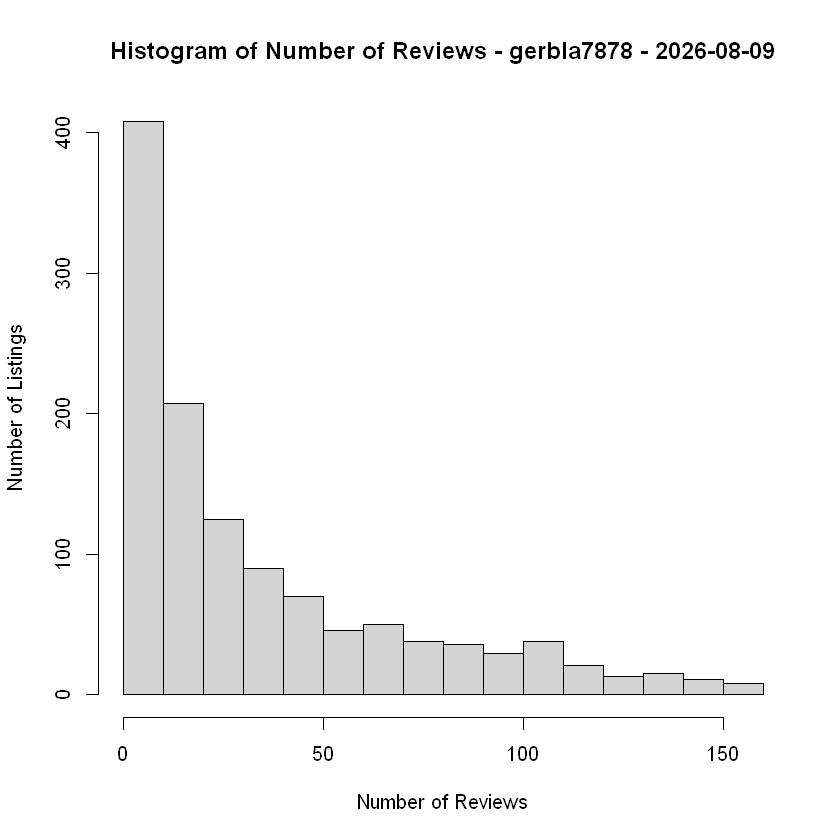

In [3]:
hist(
    df_cleaned$number_of_reviews,
    main = paste(
        "Histogram of Number of Reviews -",
        student_id,
        "-",
        todays_date
    ),
    xlab = "Number of Reviews",
    ylab = "Number of Listings",
    breaks = 20
)


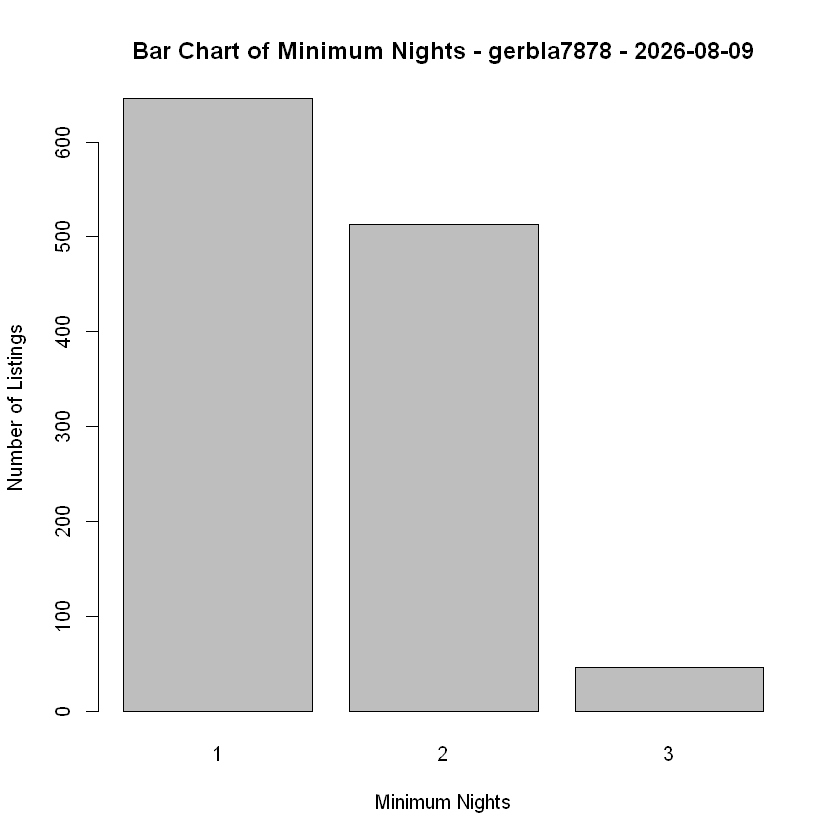

In [4]:
minimum_nights_counts <- table(
    df_cleaned$minimum_nights
)

barplot(
    minimum_nights_counts,
    main = paste(
        "Bar Chart of Minimum Nights -",
        student_id,
        "-",
        todays_date
    ),
    xlab = "Minimum Nights",
    ylab = "Number of Listings"
)

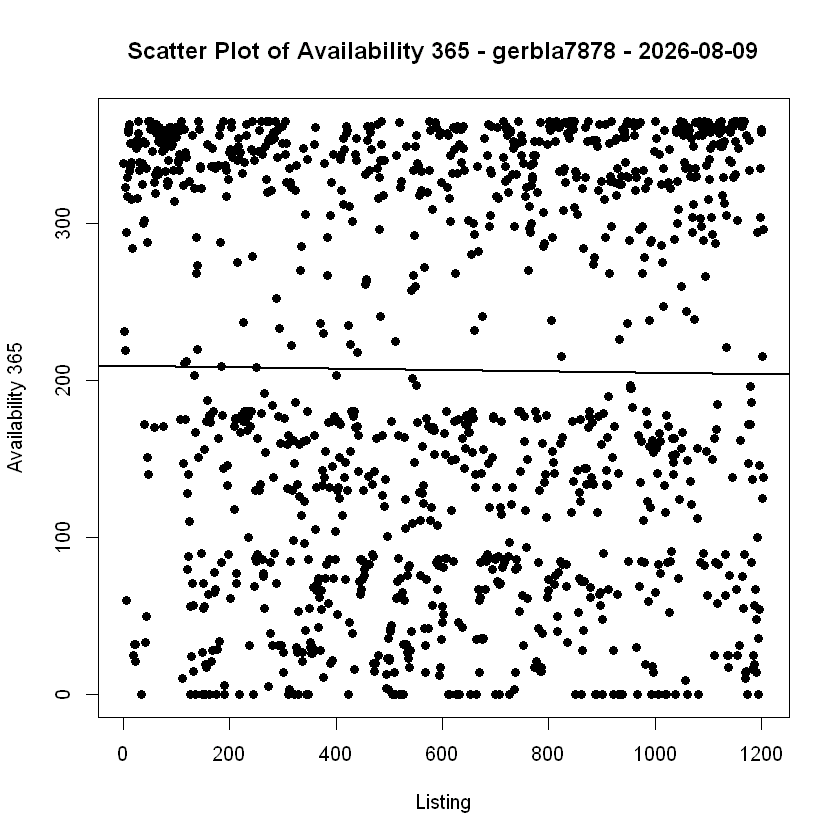

In [5]:
x <- seq_len(nrow(df_cleaned))
y <- df_cleaned$availability_365

plot(
    x,
    y,
    main = paste(
        "Scatter Plot of Availability 365 -",
        student_id,
        "-",
        todays_date
    ),
    xlab = "Listing",
    ylab = "Availability 365",
    pch = 16
)

trend_model <- lm(y ~ x)

abline(
    trend_model,
    lwd = 2
)


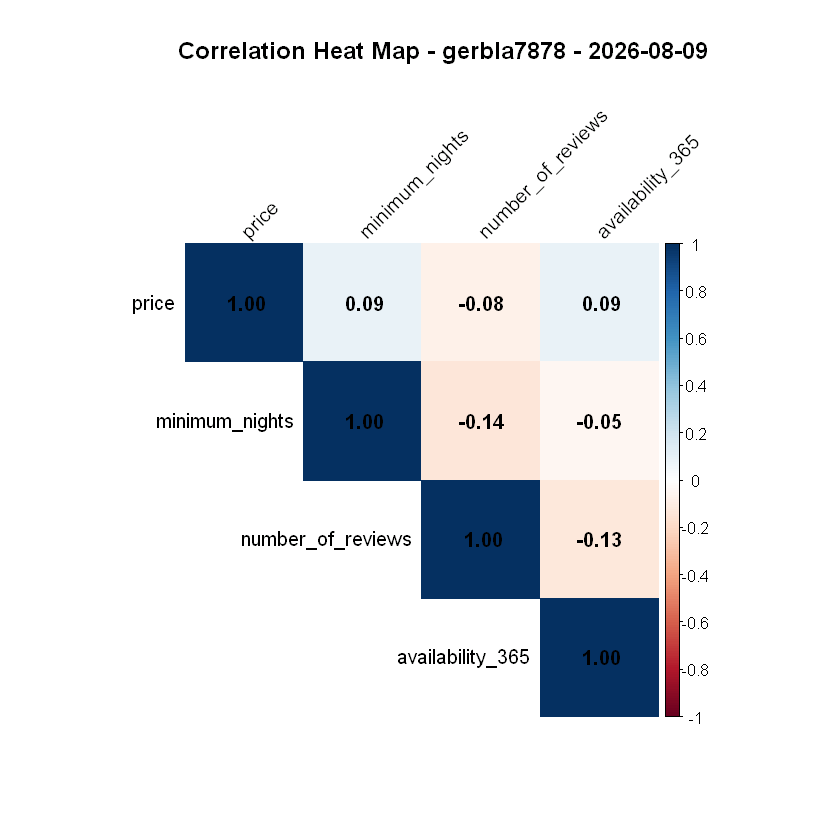

In [6]:
heatmap_columns <- df_cleaned[, c(
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
)]

correlation_matrix <- cor(
    heatmap_columns,
    use = "complete.obs"
)

corrplot(
    correlation_matrix,
    method = "color",
    type = "upper",
    addCoef.col = "black",
    tl.col = "black",
    tl.srt = 45
)

title(
    main = paste(
        "Correlation Heat Map -",
        student_id,
        "-",
        todays_date
    )
)